# Panda Arc Motion — Final Test Run (2026-07-20)

**160° arc, 8 stops, lens radius 4 cm, sweep toward −Y, manual Enter advance.**
All 8 waypoints reached — first full completion of a >90° arc on the real robot.

```
rosrun panda_moveit_ctrl panda_semicircle_motion.py _execute:=true \
    _radius:=0.04 _arc_degrees:=160 _number_of_points:=8 \
    _object_height:=0.57 _confirm_each_pose:=true
```

Every pose below is what the robot **logged after arriving**
(`arc_poses_20260720_131225.csv`), not the planned targets. The lens positions
come from the CSV's `lens_x/y/z` columns (full `_lens_xyz` rigid transform,
ultra-wide lens of the iPhone 15 Pro in the 45° cradle).

Colors: **blue** = flange path (solid) and lens path (dashed), **red** = object +
keep-out sphere, **gray** = camera sight-lines, **dark line** = support rod.

> **Axis convention:** Z-up (ROS REP 103). The arc lives in the Y–Z plane and
> descends toward **−Y**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import plotly.graph_objects as go
    HAVE_PLOTLY = True          # interactive, rotatable 3D
except ImportError:
    HAVE_PLOTLY = False
    print("plotly not installed - the 3D view will be static. "
          "Install with: pip install plotly")

BLUE = "#2a78d6"   # hand / lens trajectory
RED = "#e34948"    # object / keep-out sphere
GRAY = "#6b7280"   # camera view directions, guides
ROD = "#374151"    # support rod
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.color"] = "#e5e7eb"
plt.rcParams["grid.linewidth"] = 0.6
plt.rcParams["axes.edgecolor"] = "#9ca3af"

In [2]:
# ---- Logged run data (arc_poses_20260720_131225.csv, verbatim) -------------

CSV = """\
waypoint,angle_deg,joint1,joint2,joint3,joint4,joint5,joint6,joint7,position_x,position_y,position_z,orientation_x,orientation_y,orientation_z,orientation_w,lens_x,lens_y,lens_z
0,0.0000,-1.311025265,-0.748163031,0.586230492,-2.107346231,-0.139481221,2.123231704,0.796497996,0.357302530,-0.191612978,0.706583223,0.673916562,-0.617810007,0.313145942,0.257073691,0.436068379,-0.254339831,0.614623597
1,20.0000,-1.293066574,-0.537102050,0.522955051,-1.882300850,-0.000176165,1.831539505,0.728060375,0.357133479,-0.240290103,0.721561592,0.707817742,-0.662766167,0.202498717,0.136855110,0.436016450,-0.268146785,0.613873281
2,40.0000,-1.294329106,-0.322114911,0.476913313,-1.666987088,0.133068252,1.550749740,0.710878746,0.357267953,-0.291043798,0.718034108,0.721217243,-0.687446801,0.084385520,0.011902404,0.436133008,-0.280320702,0.607306477
3,60.0000,-1.303877326,-0.114094614,0.442002617,-1.485582420,0.278716322,1.296033129,0.738419859,0.357362824,-0.337600834,0.697276446,-0.712547424,0.691411873,0.036418932,0.113575748,0.436189293,-0.289573672,0.596901800
4,80.0000,-1.323802175,0.066994730,0.418332343,-1.373111322,0.453859375,1.085327556,0.801814196,0.357467288,-0.374337956,0.661793378,-0.682020508,0.674475995,0.156125196,0.235701258,0.436271384,-0.294823711,0.583930105
5,100.0000,-1.354691953,0.200558308,0.407380580,-1.364468274,0.658278818,0.931852268,0.885775554,0.357549153,-0.396735733,0.615879471,-0.630740250,0.636938960,0.271127219,0.350664411,0.436315202,-0.295332551,0.569960039
6,120.0000,-1.388365673,0.280149834,0.406461276,-1.462547516,0.876249608,0.829184537,0.970712384,0.357455342,-0.402299139,0.565418333,-0.560342963,0.580310159,0.377406029,0.454775300,0.436241312,-0.291323962,0.556899484
7,140.0000,-1.416740314,0.316064920,0.415526243,-1.639673399,1.097818477,0.754839427,1.048303382,0.357413489,-0.390154693,0.515813433,-0.472775757,0.505956434,0.472559947,0.545140594,0.436198223,-0.282958377,0.545766824
8,160.0000,-2.184116185,1.255801626,1.628200770,-1.976018727,0.716358167,1.470024717,1.539937072,0.355446557,-0.362017817,0.472733001,-0.360853226,0.413511725,0.552273308,0.627524657,0.435749443,-0.274270121,0.539419419
"""

rows = np.array([[float(value) for value in line.split(",")]
                 for line in CSV.strip().splitlines()[1:]])

ANGLES = rows[:, 1]              # deg; 0 = start pose (stop 0)
JOINTS = rows[:, 2:9]
FLANGE = rows[:, 9:12]
QUATS = rows[:, 12:16]           # x, y, z, w
LENS = rows[:, 16:19]

# Values logged by the script for this run
CENTER = np.array([0.437878, -0.256084, 0.574706])   # object (sphere center)
RADIUS = 0.04                                        # lens-object target (m)
KEEPOUT_R = 0.02                                     # keep-out sphere (m)
GROUND_Z = 0.005                                     # rod bottom (m, log)
LENS_AXIS_EE = np.array([-0.70711, 0.0, 0.70711])    # camera axis, link8 frame


def quat_to_matrix(q):
    x, y, z, w = q
    return np.array([
        [1 - 2*(y*y + z*z), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w)],
        [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y)],
    ])


VIEW = np.array([quat_to_matrix(q) @ LENS_AXIS_EE for q in QUATS])

to_object = CENTER - LENS
LENS_DIST = np.linalg.norm(to_object, axis=1)
AIM_ERR = np.degrees(np.arccos(np.clip(
    np.sum(VIEW * (to_object / LENS_DIST[:, None]), axis=1), -1.0, 1.0)))
TILT = np.degrees(np.arccos(np.clip(VIEW @ VIEW[0], -1.0, 1.0)))

# Image-roll consistency: the image-horizontal axis starts parallel to
# world X (the arc's rotation axis) and stays there iff the camera
# never rolls -> every photo has the same image rotation.
horiz_ee = quat_to_matrix(QUATS[0]).T @ np.array([1.0, 0.0, 0.0])
HORIZ = np.array([quat_to_matrix(q) @ horiz_ee for q in QUATS])
ROLL_ERR = np.degrees(np.arccos(np.clip(np.abs(HORIZ[:, 0]), -1.0, 1.0)))

In [3]:
# ---- Per-stop metrics ------------------------------------------------------

print("stop  angle   lens-object   aim err    tilt   roll err    joint1")
print("      (deg)       (cm)       (deg)    (deg)     (deg)      (rad)")
for i in range(len(ANGLES)):
    print("%4d  %5.0f     %6.3f     %7.3f   %6.1f   %7.3f   %8.3f" % (
        i, ANGLES[i], LENS_DIST[i] * 100, AIM_ERR[i], TILT[i],
        ROLL_ERR[i], JOINTS[i, 0]))

print()
print("lens-object distance: %.2f-%.2f cm (target %.1f cm)" % (
    LENS_DIST.min() * 100, LENS_DIST.max() * 100, RADIUS * 100))
print("aim error stops 0-7:  <= %.2f deg; stop 8: %.2f deg "
      "(pose-target fallback)" % (AIM_ERR[:-1].max(), AIM_ERR[-1]))
print("image-roll error:     <= %.2f deg (stops 0-7)"
      % ROLL_ERR[:-1].max())

stop  angle   lens-object   aim err    tilt   roll err    joint1
      (deg)       (cm)       (deg)    (deg)     (deg)      (rad)
   0      0      4.000       0.000      0.0     0.000     -1.311
   1     20      4.103       0.129     19.8     0.076     -1.293
   2     40      4.066       0.684     39.8     0.054     -1.294
   3     60      4.021       0.867     59.8     0.060     -1.304
   4     80      3.986       0.776     79.8     0.062     -1.324
   5    100      3.957       0.547     99.8     0.065     -1.355
   6    120      3.952       0.558    119.7     0.069     -1.388
   7    140      3.953       0.226    139.6     0.056     -1.417
   8    160      3.975       5.874    160.3     1.019     -2.184

lens-object distance: 3.95-4.10 cm (target 4.0 cm)
aim error stops 0-7:  <= 0.87 deg; stop 8: 5.87 deg (pose-target fallback)
image-roll error:     <= 0.08 deg (stops 0-7)


In [4]:
# ---- Interactive 3D view ---------------------------------------------------

def plot_3d():
    if not HAVE_PLOTLY:
        return plot_3d_static()

    traces = []

    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
    traces.append(go.Surface(
        x=CENTER[0] + KEEPOUT_R*np.cos(u)*np.sin(v),
        y=CENTER[1] + KEEPOUT_R*np.sin(u)*np.sin(v),
        z=CENTER[2] + KEEPOUT_R*np.cos(v),
        colorscale=[[0, RED], [1, RED]], opacity=0.30,
        showscale=False, name="keep-out sphere",
        hovertemplate="keep-out sphere<extra></extra>"))

    traces.append(go.Scatter3d(
        x=FLANGE[:, 0], y=FLANGE[:, 1], z=FLANGE[:, 2],
        mode="lines+markers+text",
        text=[str(i) for i in range(len(FLANGE))],
        textposition="top center", textfont=dict(color=BLUE, size=11),
        line=dict(color=BLUE, width=5), marker=dict(color=BLUE, size=5),
        name="flange path",
        hovertemplate="stop %{text}<br>x=%{x:.4f} y=%{y:.4f} z=%{z:.4f}"
                      "<extra>flange</extra>"))

    traces.append(go.Scatter3d(
        x=LENS[:, 0], y=LENS[:, 1], z=LENS[:, 2],
        mode="lines+markers", line=dict(color=BLUE, width=3, dash="dash"),
        marker=dict(color=BLUE, size=3), name="lens path (ultra-wide)",
        hovertemplate="x=%{x:.4f} y=%{y:.4f} z=%{z:.4f}<extra>lens</extra>"))

    xs, ys, zs = [], [], []
    for lens, view in zip(LENS, VIEW):
        tip = lens + RADIUS * view
        xs += [lens[0], tip[0], None]
        ys += [lens[1], tip[1], None]
        zs += [lens[2], tip[2], None]
    traces.append(go.Scatter3d(
        x=xs, y=ys, z=zs, mode="lines",
        line=dict(color=GRAY, width=2), name="camera direction",
        hoverinfo="skip"))

    traces.append(go.Scatter3d(
        x=[CENTER[0]], y=[CENTER[1]], z=[CENTER[2]],
        mode="markers+text", text=["object"], textposition="bottom center",
        textfont=dict(color=RED, size=12),
        marker=dict(color=RED, size=7, symbol="x"), name="object"))

    z_bottom = min(FLANGE[:, 2].min(), LENS[:, 2].min()) - 0.05
    traces.append(go.Scatter3d(
        x=[CENTER[0], CENTER[0]], y=[CENTER[1], CENTER[1]],
        z=[z_bottom, CENTER[2]], mode="lines",
        line=dict(color=ROD, width=7),
        name="support rod (to ground at z=0.005)"))

    fig = go.Figure(data=traces)
    fig.update_layout(
        title="160° arc, 8 stops, r = 4 cm, sweep -Y — drag to rotate",
        height=750, legend=dict(itemsizing="constant"),
        scene=dict(aspectmode="data",
                   xaxis_title="X (m)", yaxis_title="Y (m)",
                   zaxis_title="Z (m)"),
        margin=dict(l=0, r=0, t=50, b=0))
    fig.show()


def plot_3d_static():
    fig = plt.figure(figsize=(9, 9))
    ax = fig.add_subplot(projection="3d")

    u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
    ax.plot_surface(CENTER[0] + KEEPOUT_R*np.cos(u)*np.sin(v),
                    CENTER[1] + KEEPOUT_R*np.sin(u)*np.sin(v),
                    CENTER[2] + KEEPOUT_R*np.cos(v),
                    color=RED, alpha=0.25, linewidth=0)
    ax.plot(FLANGE[:, 0], FLANGE[:, 1], FLANGE[:, 2],
            color=BLUE, linewidth=2)
    ax.scatter(FLANGE[:, 0], FLANGE[:, 1], FLANGE[:, 2],
               color=BLUE, s=35, depthshade=False)
    ax.plot(LENS[:, 0], LENS[:, 1], LENS[:, 2],
            color=BLUE, linewidth=1.2, linestyle="--")
    ax.scatter(*CENTER, color=RED, s=80, marker="X", depthshade=False)

    everything = np.vstack([FLANGE, LENS, CENTER[None, :]])
    mid = (everything.max(axis=0) + everything.min(axis=0)) / 2
    half = everything.ptp(axis=0).max() / 2 + 0.03
    ax.set_xlim(mid[0] - half, mid[0] + half)
    ax.set_ylim(mid[1] - half, mid[1] + half)
    ax.set_zlim(mid[2] - half, mid[2] + half)
    ax.plot([CENTER[0], CENTER[0]], [CENTER[1], CENTER[1]],
            [mid[2] - half, CENTER[2]], color=ROD, linewidth=2.5)
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_zlabel("Z (m)")
    ax.view_init(elev=18, azim=-35)
    plt.tight_layout()
    plt.show()


plot_3d()

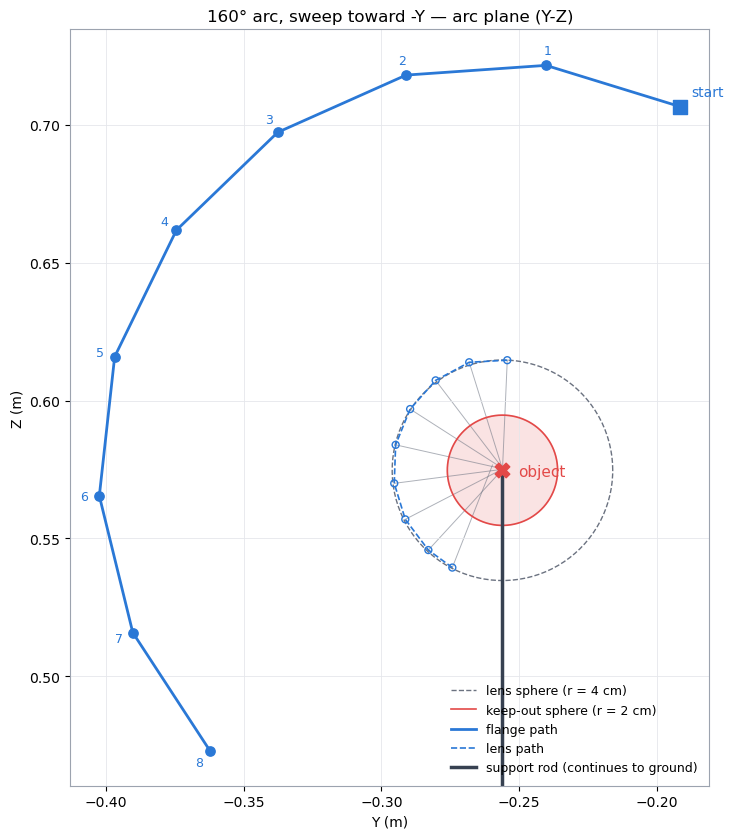

In [5]:
# ---- Arc plane (Y-Z) -------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.5, 8.5))
angle = np.linspace(0, 2*np.pi, 200)

ax.plot(CENTER[1] + RADIUS*np.cos(angle), CENTER[2] + RADIUS*np.sin(angle),
        linestyle="--", color=GRAY, linewidth=1,
        label="lens sphere (r = 4 cm)")
ax.fill(CENTER[1] + KEEPOUT_R*np.cos(angle),
        CENTER[2] + KEEPOUT_R*np.sin(angle), color=RED, alpha=0.15)
ax.plot(CENTER[1] + KEEPOUT_R*np.cos(angle),
        CENTER[2] + KEEPOUT_R*np.sin(angle), color=RED, linewidth=1.2,
        label="keep-out sphere (r = 2 cm)")

for lens, view in zip(LENS, VIEW):
    ax.plot([lens[1], lens[1] + RADIUS*view[1]],
            [lens[2], lens[2] + RADIUS*view[2]],
            color=GRAY, linewidth=0.7, alpha=0.55, zorder=1)

ax.plot(FLANGE[:, 1], FLANGE[:, 2], color=BLUE, linewidth=2, zorder=3,
        label="flange path")
ax.scatter(FLANGE[:, 1], FLANGE[:, 2], color=BLUE, s=45, zorder=4)
ax.plot(LENS[:, 1], LENS[:, 2], color=BLUE, linewidth=1.2,
        linestyle="--", zorder=3, label="lens path")
ax.scatter(LENS[:, 1], LENS[:, 2], edgecolors=BLUE, facecolors="none",
           s=25, zorder=4)

ax.scatter(FLANGE[0, 1], FLANGE[0, 2], color=BLUE, s=90, marker="s",
           zorder=4)
ax.annotate("start", (FLANGE[0, 1], FLANGE[0, 2]),
            textcoords="offset points", xytext=(8, 8), color=BLUE,
            fontsize=10)
for i, p in enumerate(FLANGE[1:], start=1):
    direction = p[1:] - CENTER[1:]
    off = 11 * direction / np.linalg.norm(direction)
    ax.annotate(str(i), (p[1], p[2]), textcoords="offset points",
                xytext=tuple(off), color=BLUE, fontsize=9,
                ha="center", va="center")

ax.scatter(CENTER[1], CENTER[2], color=RED, s=110, marker="X", zorder=4)
ax.annotate("object", (CENTER[1], CENTER[2]), textcoords="offset points",
            xytext=(28, -4), color=RED, fontsize=11, ha="center")

ax.set_aspect("equal")
z_bottom = ax.get_ylim()[0]
ax.plot([CENTER[1], CENTER[1]], [z_bottom, CENTER[2]],
        color=ROD, linewidth=2.5, zorder=2,
        label="support rod (continues to ground)")
ax.set_ylim(bottom=z_bottom)

ax.set_xlabel("Y (m)"); ax.set_ylabel("Z (m)")
ax.set_title("160° arc, sweep toward -Y — arc plane (Y-Z)")
ax.legend(loc="lower right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

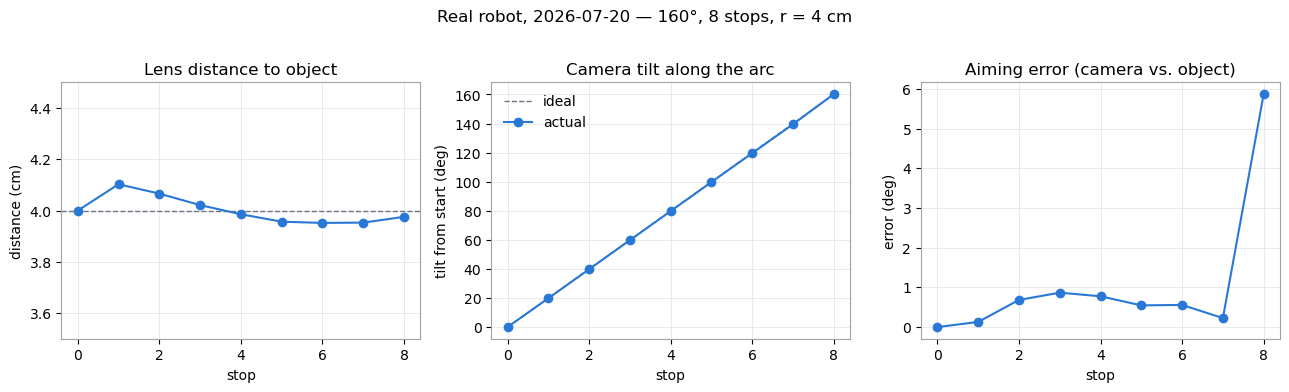

In [6]:
# ---- Quality checks per stop -----------------------------------------------

stops = np.arange(len(ANGLES))
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

axes[0].axhline(RADIUS * 100, linestyle="--", color=GRAY, linewidth=1)
axes[0].plot(stops, LENS_DIST * 100, color=BLUE, marker="o")
axes[0].set_ylim(RADIUS * 100 - 0.5, RADIUS * 100 + 0.5)
axes[0].set_title("Lens distance to object")
axes[0].set_xlabel("stop"); axes[0].set_ylabel("distance (cm)")

axes[1].plot(stops, ANGLES, linestyle="--", color=GRAY, linewidth=1,
             label="ideal")
axes[1].plot(stops, TILT, color=BLUE, marker="o", label="actual")
axes[1].set_title("Camera tilt along the arc")
axes[1].set_xlabel("stop"); axes[1].set_ylabel("tilt from start (deg)")
axes[1].legend(frameon=False)

axes[2].plot(stops, AIM_ERR, color=BLUE, marker="o")
axes[2].set_title("Aiming error (camera vs. object)")
axes[2].set_xlabel("stop"); axes[2].set_ylabel("error (deg)")

fig.suptitle("Real robot, 2026-07-20 — 160°, 8 stops, r = 4 cm", y=1.02)
plt.tight_layout()
plt.show()

## Observations

- **All 8 stops of a 160° arc were reached** — from looking straight down (stop 0)
  to looking up at the object from 20° below the side (stop 8). Coverage that
  previous +Y-sweep runs never completed.
- **Geometry held:** logged lens–object distance 3.95–4.10 cm at every stop
  (target 4.00), aim error ≤ 0.87° and image-roll ≤ 0.08° for stops 0–7.
- **The "3 cm at stop 7" observation is not in the trajectory:** the logged lens
  sits 3.95 cm from the *computed* object position there. A physically measured
  ~3 cm means the **real object was placed ~1 cm off the computed sphere center**
  (and/or the entrance pupil, which sits a couple of mm behind the fitted
  lens-ring surface, shortens the optical distance). Fix for next time: place the
  object more precisely at the logged center coordinates, and calibrate
  `_radius` against a test photo.
- **Stop 8 is the outlier:** the Cartesian segment was only 90 % feasible, the
  pose-target fallback succeeded but with a large arm reconfiguration
  (joint 1 jumped −1.42 → −2.18 rad) and landed with a **5.9° aim error**
  (position fine, ~2 mm off). If the dataset needs clean aiming, either re-shoot
  stop 8 or treat its pose from the CSV as ground truth (the pose is *known*,
  just not perfectly centered).